# Prioritized Exprience Replay (PER)
이 튜토리얼은 **Prioritized Experience Replay (PER)**를 구현하는 방법을 안내한다.

**Prioritized Experience Replay (PER)**는 에이전트가 학습할 때 모든 경험을 동일한 확률로 샘플링하는 대신, **중요한 경험(학습할 게 많은 경험, 즉 TD Error가 큰 경험)을 더 자주 샘플링**하여 학습 효율을 높이는 기법이다.

이 튜토리얼에서는 최신 라이브러리 호환성 및 실행 안정성을 위해 `Snake-v0`(픽셀 기반) 대신 `LunarLander-v2`(벡터 기반) 환경을 사용하여 PER의 핵심 로직을 구현한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [2]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습된 에이전트의 플레이 영상을 확인하기 위한 함수다.

In [3]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Dueling Deep Q-Network 생성 (Create the Dueling DQN)

원본 코드의 구조를 유지하여 Dueling Network 구조를 사용한다. 다만, `LunarLander` 환경에 맞게 입력층을 Convolution(이미지용)에서 Linear(벡터용)로 변경했다.

In [4]:
class DuelingDQN(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        """
        Dueling DQN 네트워크 초기화
        :param obs_size: 입력 상태의 차원
        :param hidden_size: 은닉층 노드 수
        :param n_actions: 출력 행동의 수
        """
        super().__init__()

        self.feature_layer = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        self.fc_adv = nn.Linear(hidden_size, n_actions)
        self.fc_value = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.feature_layer(x.float())
        adv = self.fc_adv(x)
        value = self.fc_value(x)

        # Dueling Aggregation
        return value + adv - torch.mean(adv, dim=1, keepdim=True)

### 5. 우선순위 경험 리플레이 버퍼 (Prioritized Replay Buffer)

PER의 핵심인 버퍼다. 각 경험마다 **우선순위(priority)**를 저장하고, 이를 기반으로 샘플링 확률(probability)을 계산한다. 또한, 편향된 샘플링을 보정하기 위한 **중요도 가중치(Importance Sampling Weights)**를 계산하여 반환한다.

In [5]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        """
        우선순위 리플레이 버퍼 초기화
        :param capacity: 버퍼 크기
        :param alpha: 우선순위 반영 정도 (0: 균등 샘플링, 1: 완전 우선순위 기반)
        """
        self.buffer = deque(maxlen=capacity)
        self.priorities = deque(maxlen=capacity)
        self.alpha = alpha
        self.max_priority = 1.0  # 새로운 경험은 최대로 설정하여 한 번은 꼭 학습되게 함

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        """경험과 초기 우선순위(max)를 저장한다."""
        self.buffer.append(experience)
        self.priorities.append(self.max_priority)

    def update(self, indices, errors):
        """
        학습 후 TD Error를 기반으로 우선순위를 업데이트한다.
        :param indices: 버퍼 내 인덱스 리스트
        :param errors: TD Error (절대값)
        """
        for idx, error in zip(indices, errors):
            priority = error + 1e-5 # 0이 되지 않도록 작은 값 더함
            self.priorities[idx] = priority
            self.max_priority = max(self.max_priority, priority)

    def sample(self, batch_size, beta=0.4):
        """
        우선순위에 따라 확률적으로 샘플링하고 가중치를 계산한다.
        :param beta: 중요도 가중치 보정 정도 (학습 후반부로 갈수록 1에 가까워져야 함)
        """
        total_items = len(self.buffer)

        # 우선순위를 확률로 변환 (P(i) = p_i^alpha / sum(p_k^alpha))
        prios = np.array(self.priorities, dtype=np.float64)
        probs = prios ** self.alpha
        probs /= probs.sum()

        # 확률에 기반하여 인덱스 선택
        indices = np.random.choice(total_items, batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]

        # 중요도 가중치 계산 (w_i = (N * P(i))^(-beta))
        weights = (total_items * probs[indices]) ** (-beta)
        weights /= weights.max() # 안정성을 위해 정규화

        return indices, np.array(weights, dtype=np.float32), samples

### 6. Pytorch Wrapper 클래스 (PER 구현)

학습 루프에서 `beta`를 관리하고, 손실 계산 시 `weights`를 적용하며, 역전파 후 `TD Error`를 계산하여 버퍼의 우선순위를 업데이트하는 로직을 포함한다.

In [6]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=128, lr=1e-3, capacity=100000,
                 gamma=0.99, batch_size=256, sync_rate=10,
                 alpha=0.6, beta_start=0.4):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.sync_rate = sync_rate
        self.beta = beta_start
        self.beta_increment = (1.0 - beta_start) / 100000 # Beta를 조금씩 1.0으로 증가시킴

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        n_actions = self.env.action_space.n

        # 네트워크 초기화 (Dueling DQN 사용)
        self.q_net = DuelingDQN(obs_size, hidden_size, n_actions).to(device)
        self.target_q_net = copy.deepcopy(self.q_net).to(device)

        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=lr)

        # PER 버퍼 생성
        self.buffer = PrioritizedReplayBuffer(capacity, alpha=alpha)

    def get_action(self, state, epsilon):
        if random.random() < epsilon:
            return self.env.action_space.sample()
        else:
            state_t = torch.tensor(np.array([state]), device=device)
            q_values = self.q_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return 0.0

        # 1. PER 버퍼에서 샘플링 (Beta 적용)
        self.beta = min(1.0, self.beta + self.beta_increment)
        indices, weights, batch = self.buffer.sample(self.batch_size, self.beta)

        states, actions, rewards, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), device=device)
        actions = torch.tensor(actions, device=device).unsqueeze(1)
        rewards = torch.tensor(rewards, device=device).unsqueeze(1)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), device=device)
        weights = torch.tensor(weights, device=device).unsqueeze(1) # 가중치 텐서

        # 2. Q값 계산
        state_action_values = self.q_net(states).gather(1, actions)

        # 3. 타겟 Q값 계산 (Double DQN 방식)
        with torch.no_grad():
            next_actions = self.q_net(next_states).argmax(dim=1, keepdim=True)
            next_action_values = self.target_q_net(next_states).gather(1, next_actions)
            expected_state_action_values = rewards + (1 - dones) * self.gamma * next_action_values

        # 4. TD Error 계산 (우선순위 업데이트용, 기울기 계산 X)
        td_errors = (state_action_values - expected_state_action_values).abs().detach().cpu().numpy()

        # 5. 버퍼 우선순위 업데이트
        self.buffer.update(indices, td_errors.flatten())

        # 6. 손실 계산 (Importance Sampling Weights 적용)
        # MSE Loss 대신 가중치가 적용된 Loss를 직접 계산
        loss = (weights * F.smooth_l1_loss(state_action_values, expected_state_action_values, reduction='none')).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def run_training(self, max_episodes=600, max_steps=400):
        total_rewards = []

        for episode in range(max_episodes):
            state, _ = self.env.reset()
            episode_reward = 0
            epsilon = max(0.01, 1.0 - (episode / 200))

            for step in range(max_steps):
                action = self.get_action(state, epsilon)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                self.buffer.append((state, action, reward, done, next_state))
                state = next_state
                episode_reward += reward

                self.train_step()

                if done:
                    break

            if episode % self.sync_rate == 0:
                self.target_q_net.load_state_dict(self.q_net.state_dict())

            total_rewards.append(episode_reward)

            if episode % 20 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}, Epsilon: {epsilon:.2f}, Beta: {self.beta:.2f}")

        return total_rewards

    def save_video(self, filename="per_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False
        while not done:
            action = self.get_action(state, epsilon=0.0)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 7. 학습 실행 (Training)

PER 에이전트를 생성하고 학습을 진행한다.

In [7]:
# PER + Dueling DQN 모델 생성
agent = PytorchWrapper('LunarLander-v3', hidden_size=128, lr=1e-3, alpha=0.6, beta_start=0.4)

# 학습 시작
print("PER (Prioritized Experience Replay) 학습을 시작한다...")
history = agent.run_training(max_episodes=600)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


PER (Prioritized Experience Replay) 학습을 시작한다...
Episode 0, Reward: -69.15, Epsilon: 1.00, Beta: 0.40
Episode 20, Reward: -143.18, Epsilon: 0.90, Beta: 0.41
Episode 40, Reward: -40.70, Epsilon: 0.80, Beta: 0.42
Episode 60, Reward: -123.02, Epsilon: 0.70, Beta: 0.44
Episode 80, Reward: -28.12, Epsilon: 0.60, Beta: 0.45
Episode 100, Reward: -15.40, Epsilon: 0.50, Beta: 0.47
Episode 120, Reward: 54.48, Epsilon: 0.40, Beta: 0.51
Episode 140, Reward: 25.25, Epsilon: 0.30, Beta: 0.55
Episode 180, Reward: 99.73, Epsilon: 0.10, Beta: 0.65
Episode 200, Reward: -121.29, Epsilon: 0.01, Beta: 0.68
Episode 220, Reward: 28.15, Epsilon: 0.01, Beta: 0.72
Episode 240, Reward: -116.66, Epsilon: 0.01, Beta: 0.77
Episode 260, Reward: -96.99, Epsilon: 0.01, Beta: 0.81
Episode 280, Reward: 52.07, Epsilon: 0.01, Beta: 0.85
Episode 300, Reward: 34.88, Epsilon: 0.01, Beta: 0.89
Episode 320, Reward: 20.39, Epsilon: 0.01, Beta: 0.93
Episode 340, Reward: -77.91, Epsilon: 0.01, Beta: 0.98
Episode 360, Reward: -50.9

### 8. 결과 시각화 (Visualization)

학습 결과와 영상을 확인한다.

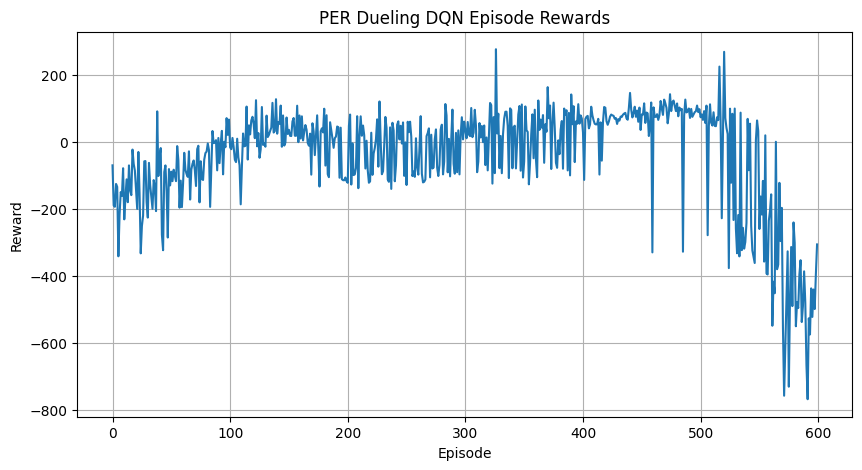

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [8]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("PER Dueling DQN Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("per-dqn")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")